# 03 - Black-box benchmark on the simulated panel

The end-to-end black box of the methodology chapter (S3.2.3): `alpha_bb_{t+1} = g_theta(x_t)`
maps the macro-financial features directly to the allocation with **no PD intermediate**,
trained end-to-end on decision regret (eq. 3.33 / 3.38).

This notebook is scoped to the black box only: it trains and evaluates
`blackbox_linear` / `blackbox_mlp` against the foresight oracle and Bayes oracle already
stored in the simulated panel (`01_simulate_pd_panel`), on the same expanding-window
protocol used everywhere else in this project. It does not re-run PTO, does not compute
persistence baselines, and does not run Diebold-Mariano tests - those live in a separate
cross-model comparison notebook that reads the per-model result CSVs each model notebook
saves (`blackbox_sim_predictions_main.csv` here). This keeps each notebook's contribution
to the thesis isolated: 01 builds the panel and the two oracles, 02 is PTO, 03 is the
black box, 04 is DFL, and comparison/DM testing is its own notebook downstream.

Shared with 02 (the fairness rule): features and timing (`x_t -> t+1`), per-window
`StandardScaler`, expanding windows with `REFIT_EVERY`, the continuous alpha optimiser
and utility constants, realised evaluation at `K_IRB_true_{t+1}`, the two-oracle regret
decomposition, and architecture capacity / hyperparameter budget (the policy networks
reuse the same linear and two-hidden-layer MLP bodies with a sigmoid head, eq. 3.30-3.31,
whose output is read directly as `alpha` - no grid snap, no PD intermediate).


In [14]:
from __future__ import annotations

import json
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar
from sklearn.preprocessing import StandardScaler

try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
except ImportError as exc:
    raise ImportError(
        "This notebook needs PyTorch for the black-box policy networks. "
        "Install the project requirements or select the project kernel."
    ) from exc

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "simulation" / "data" / "simulated_pd_panel.csv").exists():
    ROOT = ROOT.parent
import sys
sys.path.insert(0, str(ROOT))
from minou_colors import MINOU_COLORS

PANEL_CSV = ROOT / "simulation" / "data" / "simulated_pd_panel.csv"
METADATA_PATH = ROOT / "simulation" / "data" / "simulated_pd_panel_metadata.json"
FIGURES_DIR = ROOT / "simulation" / "figures" / "03_blackbox_pd_irb_sim"
RESULTS_DIR = ROOT / "simulation" / "results" / "03_blackbox"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Project root: {ROOT}")
print(f"Panel: {PANEL_CSV.relative_to(ROOT)}")
print(f"Figures: {FIGURES_DIR.relative_to(ROOT)}")
print(f"Results: {RESULTS_DIR.relative_to(ROOT)}")


Project root: /Users/hannahokeeffe/Documents/Imperial/DFL_New
Panel: simulation/data/simulated_pd_panel.csv
Figures: simulation/figures/03_blackbox_pd_irb_sim
Results: simulation/results/03_blackbox


## Configuration

Decision and Basel constants are read from the simulator's metadata JSON so this
notebook cannot silently diverge from `01_simulate_pd_panel` / `02_pto_simulated_panel`;
the asserts below fail loudly if the panel was built with different constants than
expected.

The simulated panel is long (~1000 quarters), so refitting every window is unnecessary
and slow. `REFIT_EVERY = 8` refits the scaler and policy networks every 8th test quarter
and reuses them in between (predictions are still one-step-ahead and use only past data).
`BB_SEEDS` / `BB_MODEL_CFG` pin the black box to the same seed-ensemble effort and
capacity/optimiser/early-stopping budget as the PTO MLP in 02 (fairness rule), even
though PTO itself is not re-run here.


In [15]:
with open(METADATA_PATH, "r", encoding="utf-8") as f:
    META = json.load(f)
CONST = META["constants"]

# Decision and Basel constants (from the simulator, asserted rather than assumed)
LGD = float(CONST["LGD"])
K1 = float(CONST["K1"])
LEVERAGE = float(CONST["ell"])
Y_BAR = float(CONST["Y_BAR"])
LAMBDA = float(CONST["lambda_shortfall"])
assert LGD == 0.45 and K1 == 1.0 and LEVERAGE == 10.0, "Panel constants differ from expected calibration."

# Allocation decisions are optimised continuously on [0, 1] (a bounded scalar solver,
# Brent's method) rather than snapped to a discrete grid, matching
# 01_simulate_pd_panel and 02_pto_simulated_panel.
ALPHA_BOUNDS = (0.0, 1.0)
ALPHA_OPT_XATOL = float(CONST.get("alpha_opt_xatol", 1e-10))

# Data conventions
HORIZON = 1
DATE_COL = "date"
FEATURE_COLS = list(META["feature_cols"])

BB_SEEDS = (42, 43, 44, 45, 46)
REFIT_EVERY = 8                 # 1 = strict every-window refits

EVAL_SPLITS = {
    "main": {"initial_train_frac": 0.7},
}

@dataclass
class ModelConfig:
    hidden_dim: int = 16
    lr: float = 1e-3
    weight_decay: float = 1e-4
    batch_size: int = 64
    epochs: int = 200
    patience: int = 30
    val_frac: float = 0.2
    seed: int = 42

BB_MODEL_CFG = ModelConfig()
print(f"Constants from metadata: LGD={LGD}, LEVERAGE={LEVERAGE}, Y_BAR={Y_BAR}, LAMBDA={LAMBDA}")
print(f"Features: {FEATURE_COLS}")
print(f"Black box: policy net (linear + MLP, sigmoid head -> alpha), trained on realised "
      f"regret; seeds {BB_SEEDS}; refit every {REFIT_EVERY}.")


Constants from metadata: LGD=0.45, LEVERAGE=10.0, Y_BAR=0.0168, LAMBDA=10.0
Features: ['x_growth', 'x_unemployment', 'x_credit_spread', 'x_yield_curve', 'x_house_price_growth', 'c', 'c_lag1']
Black box: policy net (linear + MLP, sigmoid head -> alpha), trained on realised regret; seeds (42, 43, 44, 45, 46); refit every 8.


## Assumptions and caveats

- **Same decision problem as the simulator**: linear shortfall penalty, and committed
  capital excluded from the available buffer (equivalent to a fixed management buffer
  add-on of `1/LEVERAGE` per unit exposure - intentional, it makes the constraint bind
  in the interior of alpha in [0, 1]).
- **Realised utility uses the true capital requirement** `K_IRB_true_{t+1}` from the
  panel, matching the simulator's oracle convention.
- **No reporting lag**: `c_t` is observable at decision time by construction (stated in
  the simulator's metadata).
- **Constant LGD, constant yield, corporate IRB curve**: inherited from the simulator by
  design so that synthetic and empirical results are comparable.
- **Training signal is hindsight-outcome information only**: per training sample the
  black box uses realised `c_{t+1}`, `K_IRB_true_{t+1}` and the panel's foresight-oracle
  utility `utility_oracle_next` as training TARGETS only - the input features are exactly
  `feature_cols`, and nothing from the panel's diagnostic-only columns is ever an input.
- **Empirical counterpart**: in the empirical notebook the training-signal capital
  requirement will be `k_irb(pd_a_realised_{t+1})`, matching how the empirical evaluation
  is done; here it is `K_IRB_true_{t+1}`, matching how every model is evaluated in this
  simulated panel.


## Allocation objective

Identical formula to the empirical notebook and to `01_simulate_pd_panel` /
`02_pto_simulated_panel`: committed capital `alpha*K1` is excluded from the available
buffer (equivalent to a `1/LEVERAGE` management buffer add-on), and the shortfall penalty
is linear. `optimise_alpha_oracle` is the continuous-optimum solver used to recompute
the foresight oracle here as a cross-notebook consistency check against the panel's
stored oracle; the black box itself does not use it during training (training
back-propagates through the continuous sigmoid output directly - see the black-box
training section below).


In [16]:
def allocation_utility(alpha, c_q, k, leverage=LEVERAGE, y_bar=Y_BAR, lambda_penalty=LAMBDA, k1=K1):
    # U(alpha; c_q, k). Buffer semantics are intentional: committed capital alpha*k1 is
    # excluded from the buffer, equivalent to a 1/leverage management buffer add-on.
    alpha = np.asarray(alpha, dtype=float)
    exposure = leverage * alpha * k1
    terminal_capital = k1 + exposure * (y_bar - float(c_q))
    committed_capital = alpha * k1
    available_buffer = terminal_capital - committed_capital
    required_capital = float(k) * exposure
    shortfall = np.maximum(required_capital - available_buffer, 0.0)
    return terminal_capital - lambda_penalty * shortfall


def decision_components(alpha, c_q, k):
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - c_q)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    required_capital = float(k) * exposure
    shortfall = max(required_capital - available_buffer, 0.0)
    utility = terminal_capital - LAMBDA * shortfall
    return dict(exposure=exposure, terminal_capital=terminal_capital, committed_capital=committed_capital,
                available_buffer=available_buffer, required_capital=required_capital, shortfall=shortfall,
                utility=utility, k_irb=float(k))


def optimise_alpha_oracle(c_q, k, leverage=LEVERAGE, y_bar=Y_BAR, lambda_penalty=LAMBDA, k1=K1):
    """Continuous-optimum allocation for one point estimate (c_q, k).

    Maximises allocation_utility(alpha; c_q, k) on [0, 1] with a bounded scalar solver
    (Brent's method via scipy.optimize.minimize_scalar), checking both domain boundaries
    explicitly. Identical objective, solver and tolerance to optimise_alpha_oracle in
    02_pto_simulated_panel and realised_alpha_star in 01_simulate_pd_panel - see the
    cross-notebook consistency check below.
    """
    def neg_utility(alpha):
        return -float(allocation_utility(alpha, c_q=c_q, k=k, leverage=leverage, y_bar=y_bar,
                                          lambda_penalty=lambda_penalty, k1=k1))

    opt = minimize_scalar(neg_utility, bounds=ALPHA_BOUNDS, method="bounded",
                           options={"xatol": ALPHA_OPT_XATOL})
    candidates = [(0.0, -neg_utility(0.0)), (1.0, -neg_utility(1.0)), (float(opt.x), -float(opt.fun))]
    return max(candidates, key=lambda item: item[1])


## Load and align the simulated panel

The forecasting row is `x_t -> quarter t+1`. Targets and evaluation columns are the
next-quarter values. Only what the black box actually needs is loaded: features, the
realised next-quarter charge-off and true capital requirement (training targets and
evaluation), and the panel's two oracle allocations/utilities (evaluation benchmarks).
There is no PD target here - the black box has no PD intermediate.


In [17]:
def load_simulated_panel(panel_csv, feature_cols, horizon=HORIZON):
    df = pd.read_csv(panel_csv)
    df[DATE_COL] = pd.PeriodIndex(df[DATE_COL], freq="Q").to_timestamp()
    df = df.sort_values(DATE_COL).reset_index(drop=True)

    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Panel is missing feature columns: {missing}")

    # Next-quarter outcomes: training targets (hindsight-only) and decision evaluation.
    df["target_date"] = df[DATE_COL].shift(-horizon)
    df["c_q_realised"] = df["c"].shift(-horizon)
    df["k_irb_true_next"] = df["K_IRB_true"].shift(-horizon)
    df["alpha_oracle_next"] = df["alpha_oracle"].shift(-horizon)
    df["utility_oracle_next"] = df["utility_oracle"].shift(-horizon)
    df["alpha_bayes_next"] = df["alpha_bayes"].shift(-horizon)
    df["utility_bayes_realised_next"] = df["utility_bayes_realised"].shift(-horizon)

    required = list(feature_cols) + ["target_date", "c_q_realised", "k_irb_true_next",
                                     "alpha_oracle_next", "utility_oracle_next",
                                     "alpha_bayes_next", "utility_bayes_realised_next"]
    df = df.dropna(subset=required).reset_index(drop=True)
    if len(df) < 100:
        raise ValueError(f"Only {len(df)} usable observations; check the panel.")
    return df

df = load_simulated_panel(PANEL_CSV, FEATURE_COLS)

forbidden = {"PD_quarterly_true", "PD_annual_true", "PD_true", "expected_c_quarterly", "K_IRB_true",
             "alpha_oracle", "alpha_bayes", "latent_state", "latent_cycle"}
assert not (forbidden & set(FEATURE_COLS)), "True/diagnostic columns leaked into features."
assert "c" in FEATURE_COLS and "c_lag1" in FEATURE_COLS
print(f"Observations after alignment: {len(df)}")
print(f"Feature date range: {df[DATE_COL].min().date()} to {df[DATE_COL].max().date()}")
display(df[[DATE_COL] + FEATURE_COLS].head())


Observations after alignment: 998
Feature date range: 1980-04-01 to 2229-07-01


,date,x_growth,x_unemployment,x_credit_spread,x_yield_curve,x_house_price_growth,c,c_lag1
0,1980-04-01,-0.203143,0.897137,-0.055082,-0.208364,0.273917,0.002093,0.001309
1,1980-07-01,-0.833491,0.699530,0.607612,-0.173439,-0.690280,0.002501,0.002093
2,1980-10-01,-0.608899,-0.001785,0.141476,0.415671,-0.206404,0.001006,0.002501
3,1981-01-01,-1.143365,-0.339549,0.567634,-0.941497,0.366174,0.001175,0.001006
4,1981-04-01,0.126592,-0.095532,-0.437445,0.586255,0.399816,0.001270,0.001175


## Black-box policy: features -> alpha, trained on realised regret

Objective (thesis eq. 3.33 / 3.38): mean realised regret over the training window,

    L_BB = (1/T) * sum_t [ U_oracle(t+1) - U(alpha_theta(x_t); c_{t+1}, K_IRB_true_{t+1}) ]

`U_oracle` does not depend on theta, so minimising mean regret is equivalent to maximising
mean realised utility; regret is kept in the loss so training/validation curves read
directly as regret. Implementation notes:

- **Architecture**: linear / two-hidden-layer MLP bodies with a sigmoid head
  (eq. 3.30-3.31), output read as `alpha in [0, 1]`, same capacity and seed ensemble as
  the PTO MLP in 02 (fairness rule), even though PTO is not re-run here.
- **Kink**: the shortfall `max(., 0)` is piecewise linear; torch subgradients handle it.
- **No grid snap**: the sigmoid output is used directly as the decision, on the same
  continuous domain [0, 1] the foresight oracle and Bayes oracle act on.
- **K in the training signal**: `K_IRB_true_{t+1}` (matches how every model is evaluated
  here); the empirical notebook will use `k_irb(pd_a_realised_{t+1})` (matches the
  empirical evaluation). Hindsight-outcome information only.
- **Early stopping on validation REGRET** (chronological tail split). The output bias is
  initialised at the mean training-window oracle allocation (also hindsight-only
  information).


In [18]:
def torch_allocation_utility(alpha, c_q, k):
    """Differentiable counterpart of allocation_utility - same constants and the same
    intentional buffer semantics (committed capital alpha*K1 excluded from the buffer).
    The kinked shortfall max(., 0) is piecewise linear; torch subgradients handle it."""
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - c_q)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    required_capital = k * exposure
    shortfall = torch.clamp(required_capital - available_buffer, min=0.0)
    return terminal_capital - LAMBDA * shortfall


class PolicyNet(nn.Module):
    # Outputs a raw score; the allocation decision is sigmoid(score), used directly with
    # no grid snap. Same linear / two-hidden-layer MLP bodies as the PTO PD forecaster in
    # 02_pto_simulated_panel (fairness rule: identical architecture, output read as alpha
    # instead of PD).
    def __init__(self, input_dim, model_type, hidden_dim=16):
        super().__init__()
        if model_type == "linear":
            self.net = nn.Linear(input_dim, 1)
        elif model_type == "mlp":
            self.net = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(),
                                     nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1))
        else:
            raise ValueError("model_type must be 'linear' or 'mlp'.")

    def forward(self, x):
        return self.net(x).squeeze(-1)


def init_output_bias_for_alpha(model, alpha_pre_val):
    # Start the policy at the mean training-window oracle allocation (hindsight-outcome
    # info, same status as the regret target itself).
    a_mean = float(np.clip(np.mean(alpha_pre_val), 0.01, 0.99))
    logit_mean = float(np.log(a_mean / (1.0 - a_mean)))
    with torch.no_grad():
        if isinstance(model.net, nn.Linear):
            model.net.bias.fill_(logit_mean)
        else:
            model.net[-1].bias.fill_(logit_mean)


def train_policy_model(x_train, c_next, k_next, u_oracle_next, alpha_oracle_next, model_type,
                       model_cfg, seed=None, return_history=False):
    """Train alpha_theta(x) by minimising mean realised regret
    U_oracle(t+1) - U(alpha_theta(x_t); c_{t+1}, K_{t+1}) over the training window.
    U_oracle is constant in theta, so this equals maximising mean realised utility; it is
    kept in the loss so the train/val curves read directly as regret. Early stopping
    monitors VALIDATION REGRET on the chronological tail."""
    seed = model_cfg.seed if seed is None else int(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    n = x_train.shape[0]
    val_size = max(1, int(np.floor(model_cfg.val_frac * n)))
    train_size = n - val_size
    if train_size < 8:
        raise ValueError("Training set too small after validation split.")

    def to_t(a):
        return torch.tensor(np.asarray(a, dtype=float), dtype=torch.float32)

    x_tr, x_val = x_train[:train_size], x_train[train_size:]
    c_tr, c_val = c_next[:train_size], c_next[train_size:]
    k_tr, k_val = k_next[:train_size], k_next[train_size:]
    u_tr, u_val = u_oracle_next[:train_size], u_oracle_next[train_size:]

    train_ds = TensorDataset(to_t(x_tr), to_t(c_tr), to_t(k_tr), to_t(u_tr))
    loader_gen = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=model_cfg.batch_size, shuffle=True, generator=loader_gen)

    model = PolicyNet(input_dim=x_train.shape[1], model_type=model_type, hidden_dim=model_cfg.hidden_dim)
    init_output_bias_for_alpha(model, alpha_oracle_next[:train_size])
    optimiser = torch.optim.AdamW(model.parameters(), lr=model_cfg.lr, weight_decay=model_cfg.weight_decay)

    def regret_loss(score, cb, kb, ub):
        alpha = torch.sigmoid(score)
        return torch.mean(ub - torch_allocation_utility(alpha, cb, kb))

    x_val_t, c_val_t, k_val_t, u_val_t = to_t(x_val), to_t(c_val), to_t(k_val), to_t(u_val)
    best_state, best_val, stale_epochs, history = None, float("inf"), 0, []

    for epoch in range(model_cfg.epochs):
        model.train()
        batch_losses = []
        for xb, cb, kb, ub in train_loader:
            optimiser.zero_grad()
            loss = regret_loss(model(xb), cb, kb, ub)
            loss.backward()
            optimiser.step()
            batch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            score_val = model(x_val_t)
            val_regret = regret_loss(score_val, c_val_t, k_val_t, u_val_t).item()
            alpha_val = torch.sigmoid(score_val).cpu().numpy()
        history.append({"epoch": epoch + 1, "model": f"blackbox_{model_type}", "seed": seed,
                        "train_loss": float(np.mean(batch_losses)), "val_loss": float(val_regret),
                        "val_mean_alpha": float(np.mean(alpha_val))})

        if val_regret < best_val - 1e-12:
            best_val, stale_epochs = val_regret, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            stale_epochs += 1
        if stale_epochs >= model_cfg.patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return (model, pd.DataFrame(history)) if return_history else model


def predict_alpha(model, x):
    # Continuous policy output in [0, 1], used directly with no grid snap anywhere in
    # the pipeline (ensemble averaging is over this same continuous value).
    model.eval()
    with torch.no_grad():
        alpha = torch.sigmoid(model(torch.tensor(x, dtype=torch.float32))).cpu().numpy()
    return np.clip(np.atleast_1d(alpha), 0.0, 1.0)


def train_policy_ensemble(x_train, c_next, k_next, u_oracle_next, alpha_oracle_next, model_cfg,
                          seeds=BB_SEEDS, return_history=False):
    models, first_hist = [], None
    for i, s in enumerate(seeds):
        want_hist = return_history and i == 0
        out = train_policy_model(x_train, c_next, k_next, u_oracle_next, alpha_oracle_next, "mlp",
                                 model_cfg, seed=s, return_history=want_hist)
        if want_hist:
            model, first_hist = out
        else:
            model = out
        models.append(model)
    return models, first_hist


def predict_alpha_ensemble(models, x):
    preds = np.stack([predict_alpha(m, x) for m in models], axis=0)
    return preds.mean(axis=0), preds.std(axis=0)


## Expanding-window evaluation

The black box is trained at each refit on the same expanding window and the same fitted
scaler that would be used for any other model in this project (`blackbox_linear` single
seed, `blackbox_mlp` seed ensemble whose continuous alphas are averaged directly, with no
grid snap anywhere - the alpha-level analogue of averaging a PD-forecaster MLP ensemble's
predictions). The perfect-foresight oracle is recomputed here from
`(c_{t+1}, K_IRB_true_{t+1})` and cross-checked against the panel's stored oracle; the
Bayes oracle comes directly from the panel. Both regrets are recorded per model: `regret`
(vs foresight oracle, >= 0 by construction) and `regret_vs_bayes` (vs the realised utility
of the Bayes allocation - can be negative on lucky draws, so only its mean is meaningful).


In [19]:
def build_result_row_alpha(base_row, alpha_hat, model_name, split_name, alpha_hat_std=float("nan")):
    """Black box enters the harness at the ALPHA level: there is no PD intermediate, so
    the decision is alpha_hat directly (the continuous policy-network output, no grid
    snap - the same continuous domain [0, 1] the oracle acts on)."""
    alpha_hat = float(alpha_hat)
    c_q_realised = float(base_row["c_q_realised"])
    k_true = float(base_row["k_irb_true_next"])
    alpha_oracle, utility_oracle = optimise_alpha_oracle(c_q=c_q_realised, k=k_true)
    realised = decision_components(alpha_hat, c_q=c_q_realised, k=k_true)
    regret = utility_oracle - realised["utility"]
    utility_bayes_realised = float(base_row["utility_bayes_realised_next"])

    return {"split": split_name, "model": model_name, "date": pd.to_datetime(base_row["target_date"]),
            "feature_date": pd.to_datetime(base_row[DATE_COL]),
            "c_q_realised": c_q_realised, "k_irb_true": k_true,
            "alpha_oracle": alpha_oracle, "alpha_bayes": float(base_row["alpha_bayes_next"]),
            "alpha_hat": alpha_hat, "alpha_hat_std": float(alpha_hat_std),
            "utility_oracle": utility_oracle, "utility_bayes_realised": utility_bayes_realised,
            "utility": realised["utility"],
            "regret": regret,
            "regret_vs_bayes": utility_bayes_realised - realised["utility"],
            "regret_irreducible": utility_oracle - utility_bayes_realised,
            "alpha_oracle_panel": float(base_row["alpha_oracle_next"]),
            "utility_oracle_panel": float(base_row["utility_oracle_next"]),
            "shortfall_realised_at_hat": realised["shortfall"]}


def resolve_first_test_idx(df, split_cfg):
    if "initial_train_frac" in split_cfg:
        first_test_idx = int(np.floor(len(df) * float(split_cfg["initial_train_frac"])))
    elif "first_test_date" in split_cfg:
        mask = (df["target_date"] >= pd.Timestamp(split_cfg["first_test_date"])).to_numpy()
        if not mask.any():
            raise ValueError("first_test_date is after the last available target date.")
        first_test_idx = int(np.flatnonzero(mask)[0])
    else:
        raise ValueError("Split config needs 'initial_train_frac' or 'first_test_date'.")
    if first_test_idx < 50 or len(df) - first_test_idx < 20:
        raise ValueError(f"Split leaves too little data: first_test_idx={first_test_idx} of {len(df)}.")
    return first_test_idx


def run_expanding_window_sim(df, feature_cols, split_name, split_cfg, model_cfg=BB_MODEL_CFG,
                             refit_every=REFIT_EVERY, return_history=True):
    first_test_idx = resolve_first_test_idx(df, split_cfg)
    total = len(df) - first_test_idx
    n_refits = int(np.ceil(total / refit_every))
    print(f"[{split_name}] first test target: {pd.Timestamp(df['target_date'].iloc[first_test_idx]).date()}, "
          f"{total} windows, {n_refits} refits (every {refit_every}), {first_test_idx} initial training obs")
    records, histories = [], []
    scaler, bb_linear_model, bb_mlp_models = None, None, None
    t0 = time.time()
    for step, test_idx in enumerate(range(first_test_idx, len(df))):
        test_row = df.iloc[test_idx]
        if step % refit_every == 0:
            train_df = df.iloc[:test_idx]
            scaler = StandardScaler()
            x_train = scaler.fit_transform(train_df[feature_cols].to_numpy(dtype=float))
            # Black box targets are hindsight outcomes (realised c_{t+1},
            # K_IRB_true_{t+1}, foresight-oracle utility/allocation).
            c_next_tr = train_df["c_q_realised"].to_numpy(dtype=float)
            k_next_tr = train_df["k_irb_true_next"].to_numpy(dtype=float)
            u_oracle_tr = train_df["utility_oracle_next"].to_numpy(dtype=float)
            alpha_oracle_tr = train_df["alpha_oracle_next"].to_numpy(dtype=float)
            bb_linear_model, bb_linear_hist = train_policy_model(
                x_train, c_next_tr, k_next_tr, u_oracle_tr, alpha_oracle_tr, "linear",
                model_cfg, return_history=True)
            bb_mlp_models, bb_mlp_hist = train_policy_ensemble(
                x_train, c_next_tr, k_next_tr, u_oracle_tr, alpha_oracle_tr, model_cfg,
                return_history=True)
            if return_history:
                for hist in (bb_linear_hist, bb_mlp_hist):
                    if hist is not None:
                        hist = hist.copy()
                        hist["split"] = split_name
                        hist["test_date"] = pd.to_datetime(test_row["target_date"])
                        hist["train_end_date"] = pd.to_datetime(train_df[DATE_COL].iloc[-1])
                        histories.append(hist)
        x_test = scaler.transform(test_row[feature_cols].to_numpy(dtype=float).reshape(1, -1))

        records.append(build_result_row_alpha(test_row, float(predict_alpha(bb_linear_model, x_test)[0]),
                                              "blackbox_linear", split_name))
        bb_mean, bb_std = predict_alpha_ensemble(bb_mlp_models, x_test)
        records.append(build_result_row_alpha(test_row, float(bb_mean[0]), "blackbox_mlp", split_name,
                                              alpha_hat_std=float(bb_std[0])))

        done = step + 1
        if done % 25 == 0 or test_idx == len(df) - 1:
            print(f"[{split_name}] completed {done}/{total} windows ({time.time() - t0:.0f}s elapsed)")
    pred_long = pd.DataFrame(records).sort_values(["date", "model"]).reset_index(drop=True)
    history = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
    return pred_long, history


split_frames, split_histories = [], []
for split_name, split_cfg in EVAL_SPLITS.items():
    pl, th = run_expanding_window_sim(df, FEATURE_COLS, split_name, split_cfg)
    split_frames.append(pl)
    split_histories.append(th)
pred_long = pd.concat(split_frames, ignore_index=True)
training_history = pd.concat([h for h in split_histories if not h.empty], ignore_index=True)
display(pred_long.head())


[main] first test target: 2155-01-01, 300 windows, 38 refits (every 8), 698 initial training obs
[main] completed 25/300 windows (36s elapsed)
[main] completed 50/300 windows (67s elapsed)
[main] completed 75/300 windows (179s elapsed)
[main] completed 100/300 windows (246s elapsed)
[main] completed 125/300 windows (342s elapsed)
[main] completed 150/300 windows (427s elapsed)
[main] completed 175/300 windows (495s elapsed)
[main] completed 200/300 windows (605s elapsed)
[main] completed 225/300 windows (802s elapsed)
[main] completed 250/300 windows (1051s elapsed)
[main] completed 275/300 windows (1305s elapsed)
[main] completed 300/300 windows (1361s elapsed)


,split,model,date,feature_date,c_q_realised,k_irb_true,alpha_oracle,alpha_bayes,alpha_hat,alpha_hat_std,utility_oracle,utility_bayes_realised,utility,regret,regret_vs_bayes,regret_irreducible,alpha_oracle_panel,utility_oracle_panel,shortfall_realised_at_hat
0,main,blackbox_linear,2155-01-01,2154-10-01,0.001512,0.069784,0.647264,0.645727,0.558462,NaN,1.098953,1.098718,1.085377,0.013576,0.013341,0.000235,0.647264,1.098953,0.0
1,main,blackbox_mlp,2155-01-01,2154-10-01,0.001512,0.069784,0.647264,0.645727,0.575459,0.008070,1.098953,1.098718,1.087975,0.010977,0.010742,0.000235,0.647264,1.098953,0.0
2,main,blackbox_linear,2155-04-01,2155-01-01,0.001526,0.080146,0.606530,0.602278,0.569962,NaN,1.092639,1.091990,1.087054,0.005585,0.004936,0.000649,0.606530,1.092639,0.0
3,main,blackbox_mlp,2155-04-01,2155-01-01,0.001526,0.080146,0.606530,0.602278,0.591573,0.003598,1.092639,1.091990,1.090355,0.002285,0.001635,0.000649,0.606530,1.092639,0.0
4,main,blackbox_linear,2155-07-01,2155-04-01,0.000854,0.078826,0.613950,0.607549,0.550877,NaN,1.097902,1.096881,1.087844,0.010058,0.009037,0.001021,0.613950,1.097902,0.0


## Result collection

Saves one wide CSV per split, `blackbox_sim_predictions_<split>.csv`, with one row per
date and per-model columns for `blackbox_linear` and `blackbox_mlp`. This is the file the
downstream cross-model comparison notebook reads alongside the equivalent PTO and DFL
CSVs (matching the pattern already used for `02_pto`'s `pto_sim_predictions_main.csv`).


In [20]:
base_cols = ["date", "c_q_realised", "k_irb_true", "alpha_oracle", "utility_oracle",
             "alpha_bayes", "utility_bayes_realised", "regret_irreducible"]
metric_cols = ["alpha_hat", "alpha_hat_std", "utility", "regret", "regret_vs_bayes"]
MODEL_ORDER = ["blackbox_linear", "blackbox_mlp"]

def make_wide_results(pred_long, split_name):
    sub = pred_long[pred_long["split"] == split_name]
    wide = sub.pivot(index="date", columns="model", values=metric_cols).sort_index()
    wide.columns = [f"{metric}_{model}" for metric, model in wide.columns]
    wide = wide.reset_index()
    base = sub[sub["model"] == "blackbox_linear"][base_cols].copy()
    out = base.merge(wide, on="date", how="left")
    ordered = base_cols + [f"{m}_{mod}" for m in metric_cols for mod in MODEL_ORDER]
    return out[ordered].sort_values("date").reset_index(drop=True)

results_by_split = {}
for split_name in EVAL_SPLITS:
    res = make_wide_results(pred_long, split_name)
    results_by_split[split_name] = res
    output_csv = RESULTS_DIR / f"blackbox_sim_predictions_{split_name}.csv"
    res.to_csv(output_csv, index=False)
    print(f"[{split_name}] saved {len(res)} rows to {output_csv.relative_to(ROOT)}")
display(results_by_split["main"].head())


[main] saved 300 rows to simulation/results/03_blackbox/blackbox_sim_predictions_main.csv


,date,c_q_realised,k_irb_true,alpha_oracle,utility_oracle,alpha_bayes,utility_bayes_realised,regret_irreducible,alpha_hat_blackbox_linear,alpha_hat_blackbox_mlp,alpha_hat_std_blackbox_linear,alpha_hat_std_blackbox_mlp,utility_blackbox_linear,utility_blackbox_mlp,regret_blackbox_linear,regret_blackbox_mlp,regret_vs_bayes_blackbox_linear,regret_vs_bayes_blackbox_mlp
0,2155-01-01,0.001512,0.069784,0.647264,1.098953,0.645727,1.098718,0.000235,0.558462,0.575459,NaN,0.008070,1.085377,1.087975,0.013576,0.010977,0.013341,0.010742
1,2155-04-01,0.001526,0.080146,0.606530,1.092639,0.602278,1.091990,0.000649,0.569962,0.591573,NaN,0.003598,1.087054,1.090355,0.005585,0.002285,0.004936,0.001635
2,2155-07-01,0.000854,0.078826,0.613950,1.097902,0.607549,1.096881,0.001021,0.550877,0.557862,NaN,0.004061,1.087844,1.088958,0.010058,0.008944,0.009037,0.007923
3,2155-10-01,0.000709,0.074619,0.630804,1.101505,0.624839,1.100546,0.000960,0.527870,0.539610,NaN,0.007824,1.084942,1.086831,0.016564,0.014674,0.015604,0.013715
4,2156-01-01,0.001102,0.077474,0.618139,1.097036,0.613022,1.096232,0.000803,0.539389,0.559006,NaN,0.007561,1.084673,1.087753,0.012362,0.009283,0.011559,0.008479


## Regret summary and sanity checks

Includes the cross-notebook consistency check: the foresight oracle recomputed here must
match the oracle stored in the simulated panel (same constants, same continuous optimum).
This is a load/alignment sanity check, not a model comparison - cross-model statistical
comparison (Diebold-Mariano etc.) happens in the separate comparison notebook.


In [21]:
def describe_columns(frame, cols):
    return frame[cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

print(f"BB seeds: {BB_SEEDS}; refit every: {REFIT_EVERY}")

bb_alpha = pred_long["alpha_hat"].to_numpy()
assert np.isfinite(bb_alpha).all() and (bb_alpha >= 0.0).all() and (bb_alpha <= 1.0).all()

# Cross-notebook consistency: recomputed foresight oracle vs the panel's stored oracle.
assert np.allclose(pred_long["alpha_oracle"], pred_long["alpha_oracle_panel"], atol=1e-9), \
    "Recomputed oracle allocation disagrees with the simulated panel - constants differ."
assert np.allclose(pred_long["utility_oracle"], pred_long["utility_oracle_panel"], atol=1e-9), \
    "Recomputed oracle utility disagrees with the simulated panel."
print("Cross-notebook oracle consistency check passed.")

min_regret = pred_long["regret"].min()
if min_regret < -1e-10:
    raise AssertionError(f"Meaningfully negative foresight regret found: {min_regret}")
assert (pred_long["regret_irreducible"] >= -1e-10).all()
print(f"Minimum foresight regret: {min_regret:.3e}")

# Decomposition identity check: regret = regret_vs_bayes + irreducible, per period.
identity_gap = (pred_long["regret"] - pred_long["regret_vs_bayes"] - pred_long["regret_irreducible"]).abs().max()
assert identity_gap < 1e-10, f"Regret decomposition identity violated: {identity_gap}"
print(f"Regret decomposition identity holds (max gap {identity_gap:.1e}).")

def regret_summary_table(sub):
    rows = []
    for model_name, g in sub.groupby("model"):
        rows.append({"model": model_name, "n": int(len(g)),
                     "mean_regret": float(g["regret"].mean()),
                     "median_regret": float(g["regret"].median()),
                     "mean_regret_vs_bayes": float(g["regret_vs_bayes"].mean()),
                     "mean_regret_irreducible": float(g["regret_irreducible"].mean()),
                     "mean_utility": float(g["utility"].mean()),
                     "shortfall_bind_share": float((g["shortfall_realised_at_hat"] > 1e-12).mean())})
    return pd.DataFrame(rows).set_index("model").loc[MODEL_ORDER]

for split_name in EVAL_SPLITS:
    sub = pred_long[pred_long["split"] == split_name]
    print(f"=== {split_name} split ===")
    metrics = regret_summary_table(sub)
    display(metrics)
    metrics.to_csv(RESULTS_DIR / f"blackbox_sim_metrics_{split_name}.csv")

summary_cols = (["c_q_realised", "k_irb_true", "alpha_oracle", "alpha_bayes"]
                + [f"alpha_hat_{m}" for m in MODEL_ORDER]
                + [f"regret_{m}" for m in MODEL_ORDER] + ["regret_irreducible"])
for split_name, res in results_by_split.items():
    print(f"=== {split_name} split summary ===")
    display(describe_columns(res, summary_cols))

bb_std_desc = pred_long[pred_long["model"] == "blackbox_mlp"].groupby("split")["alpha_hat_std"].describe()
print("Cross-seed std of black-box MLP ensemble alphas (per split):")
display(bb_std_desc)


BB seeds: (42, 43, 44, 45, 46); refit every: 8
Cross-notebook oracle consistency check passed.
Minimum foresight regret: 4.708e-05
Regret decomposition identity holds (max gap 0.0e+00).
=== main split ===


,n,mean_regret,median_regret,mean_regret_vs_bayes,mean_regret_irreducible,mean_utility,shortfall_bind_share
model,,,,,,,
blackbox_linear,300,0.015998,0.016590,0.014971,0.001027,1.084894,0.010000
blackbox_mlp,300,0.014825,0.014209,0.013797,0.001027,1.086067,0.006667


=== main split summary ===


,count,mean,std,min,5%,25%,50%,75%,95%,max
c_q_realised,300.0,0.001453,0.001512,0.000149,0.000321,0.000526,0.000799,0.001785,0.005251,0.011175
k_irb_true,300.0,0.071844,0.020529,0.050463,0.051418,0.054169,0.063588,0.087909,0.112072,0.120071
alpha_oracle,300.0,0.650429,0.082586,0.468060,0.499106,0.578515,0.677970,0.724801,0.740374,0.746420
alpha_bayes,300.0,0.646207,0.084147,0.470035,0.492615,0.572617,0.674301,0.722309,0.737535,0.742963
alpha_hat_blackbox_linear,300.0,0.553649,0.051711,0.404217,0.461276,0.523250,0.559736,0.584462,0.633958,0.704033
alpha_hat_blackbox_mlp,300.0,0.565535,0.065412,0.313599,0.440432,0.521085,0.580469,0.613647,0.649967,0.679639
regret_blackbox_linear,300.0,0.015998,0.009096,0.000320,0.002759,0.008961,0.016590,0.021750,0.026782,0.072990
regret_blackbox_mlp,300.0,0.014825,0.018560,0.000047,0.002958,0.009367,0.014209,0.017731,0.022418,0.255582
regret_irreducible,300.0,0.001027,0.005322,0.000017,0.000239,0.000454,0.000600,0.000786,0.001214,0.088381


Cross-seed std of black-box MLP ensemble alphas (per split):


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
main,300.0,0.012278,0.00763,0.001415,0.006723,0.010436,0.016271,0.04993


## Plots

Figures per split into `figures/03_blackbox_pd_irb_sim/<split>/`. There is no PD stage to
plot for the black box, so the figures here cover allocation and regret only.


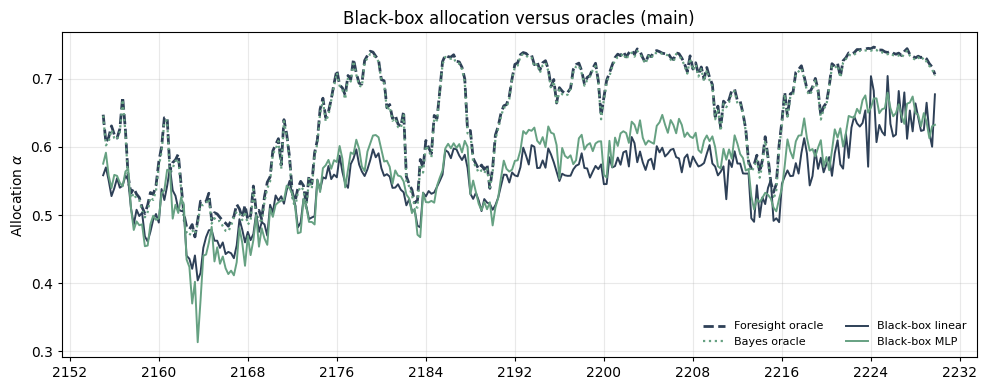

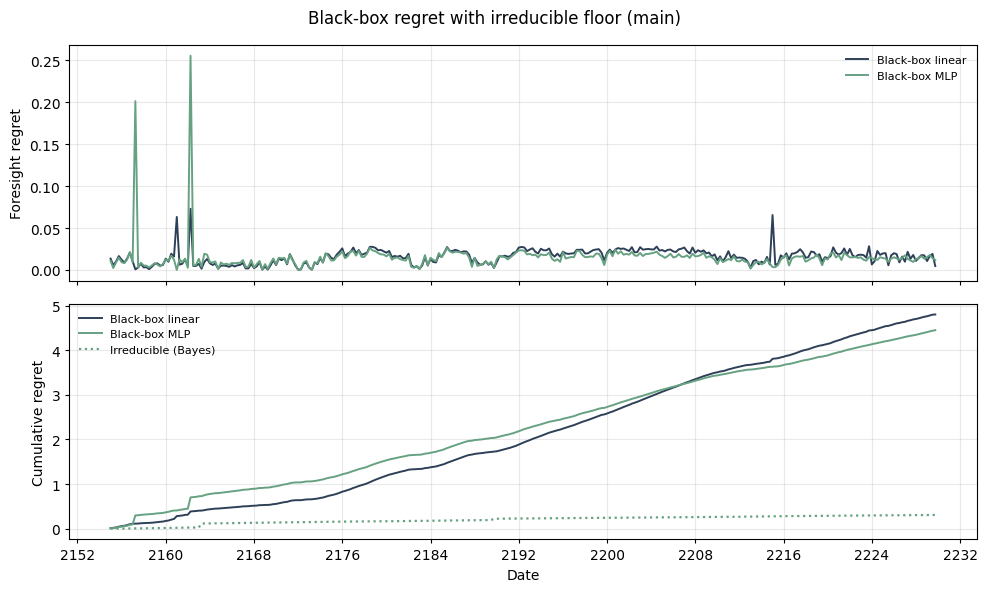

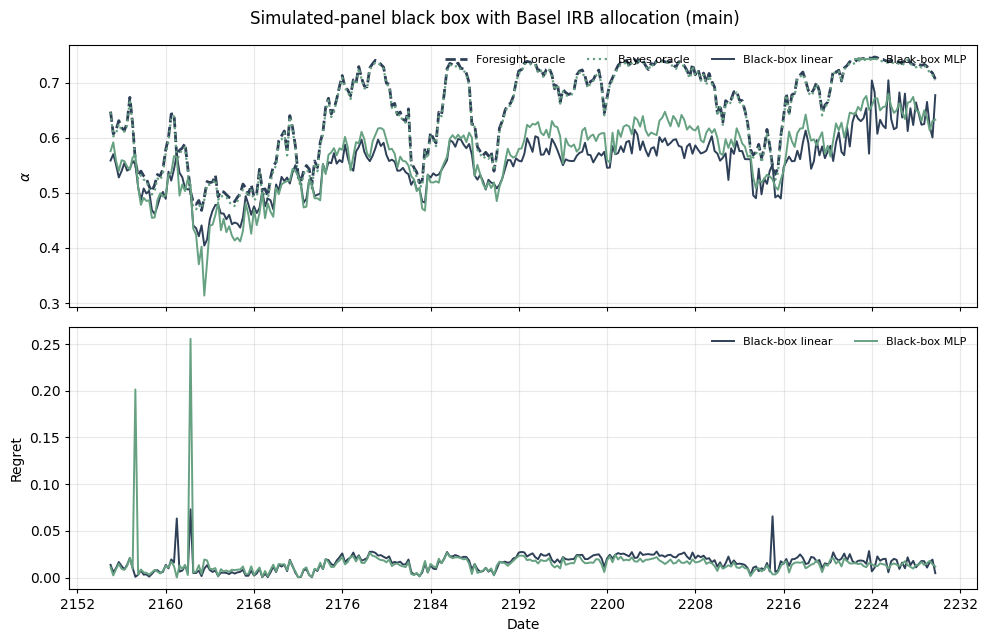

In [22]:
plt.rcdefaults()
plt.rcParams.update({"font.size": 10, "axes.linewidth": 0.8, "xtick.direction": "out", "ytick.direction": "out",
                     "xtick.major.size": 3, "ytick.major.size": 3, "font.sans-serif": ["DejaVu Sans"]})
MODEL_COLORS = {"blackbox_linear": MINOU_COLORS["navy"], "blackbox_mlp": MINOU_COLORS["sage"]}
MODEL_LW = {"blackbox_linear": 1.4, "blackbox_mlp": 1.4}
MODEL_LABELS = {"blackbox_linear": "Black-box linear", "blackbox_mlp": "Black-box MLP"}
ORACLE_COLOR = MINOU_COLORS["navy"]
BAYES_COLOR = MINOU_COLORS["sage"]

def format_date_axis(ax, plot_df):
    years = plot_df["date"].dt.year
    step = max(2, int(np.ceil((years.max() - years.min()) / 10)))
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.28)


def plot_split(res, split_name):
    fig_dir = FIGURES_DIR / split_name
    fig_dir.mkdir(parents=True, exist_ok=True)
    plot_df = res.sort_values("date").copy()

    # 1. Allocations: foresight oracle, Bayes oracle, black box
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Foresight oracle")
    ax.plot(plot_df["date"], plot_df["alpha_bayes"], color=BAYES_COLOR, lw=1.6, ls=":", label="Bayes oracle")
    for m in MODEL_ORDER:
        ax.plot(plot_df["date"], plot_df[f"alpha_hat_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    ax.set_ylabel(r"Allocation $\alpha$"); ax.set_title(f"Black-box allocation versus oracles ({split_name})")
    format_date_axis(ax, plot_df); ax.legend(frameon=False, fontsize=8, ncol=2); plt.tight_layout()
    plt.savefig(fig_dir / "allocation_comparison.png", dpi=200, bbox_inches="tight"); plt.show()

    # 2. Regret and cumulative regret, with the irreducible floor
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    for m in MODEL_ORDER:
        axes[0].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
        axes[1].plot(plot_df["date"], plot_df[f"regret_{m}"].cumsum(), color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    axes[1].plot(plot_df["date"], plot_df["regret_irreducible"].cumsum(), color=BAYES_COLOR, lw=1.6, ls=":",
                 label="Irreducible (Bayes)")
    axes[0].set_ylabel("Foresight regret"); axes[0].legend(frameon=False, fontsize=8)
    axes[1].set_ylabel("Cumulative regret"); axes[1].set_xlabel("Date"); axes[1].legend(frameon=False, fontsize=8)
    for ax in axes:
        format_date_axis(ax, plot_df)
    fig.suptitle(f"Black-box regret with irreducible floor ({split_name})"); plt.tight_layout()
    plt.savefig(fig_dir / "regret.png", dpi=200, bbox_inches="tight"); plt.show()

    # 3. Compact thesis figure: allocation + regret
    fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
    fig.subplots_adjust(hspace=0.08)
    axes[0].plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Foresight oracle")
    axes[0].plot(plot_df["date"], plot_df["alpha_bayes"], color=BAYES_COLOR, lw=1.6, ls=":", label="Bayes oracle")
    for m in MODEL_ORDER:
        axes[0].plot(plot_df["date"], plot_df[f"alpha_hat_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    axes[0].set_ylabel(r"$\alpha$")
    for m in MODEL_ORDER:
        axes[1].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    axes[1].set_ylabel("Regret"); axes[1].set_xlabel("Date")
    for ax in axes:
        format_date_axis(ax, plot_df); ax.legend(fontsize=8, frameon=False, loc="upper right", ncol=4)
    fig.suptitle(f"Simulated-panel black box with Basel IRB allocation ({split_name})", fontsize=12)
    plt.tight_layout(); plt.savefig(fig_dir / "blackbox_sim_compact_panel.png", dpi=220, bbox_inches="tight"); plt.show()


for split_name, res in results_by_split.items():
    plot_split(res, split_name)


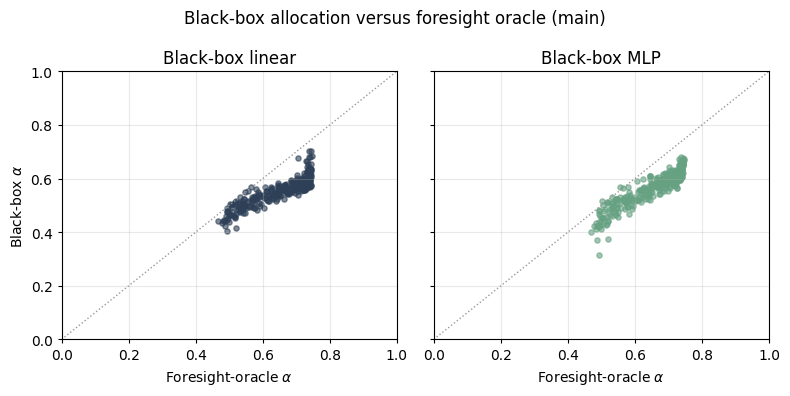

In [23]:
# 2. Black-box alpha vs oracle alpha scatter
for split_name, res in results_by_split.items():
    plot_df = res.sort_values("date").copy()
    fig_dir = FIGURES_DIR / split_name
    fig_dir.mkdir(parents=True, exist_ok=True)
    fig, axes_bb = plt.subplots(1, len(MODEL_ORDER), figsize=(4 * len(MODEL_ORDER), 4), sharex=True, sharey=True)
    for ax_i, m in zip(np.atleast_1d(axes_bb), MODEL_ORDER):
        ax_i.scatter(plot_df["alpha_oracle"], plot_df[f"alpha_hat_{m}"], s=14, color=MODEL_COLORS[m], alpha=0.6)
        ax_i.plot([0, 1], [0, 1], color="#999999", lw=1, ls=":")
        ax_i.set_xlim(0, 1); ax_i.set_ylim(0, 1)
        ax_i.set_title(MODEL_LABELS[m]); ax_i.set_xlabel(r"Foresight-oracle $\alpha$")
        ax_i.grid(True, alpha=0.28)
    np.atleast_1d(axes_bb)[0].set_ylabel(r"Black-box $\alpha$")
    fig.suptitle(f"Black-box allocation versus foresight oracle ({split_name})")
    plt.tight_layout(); plt.savefig(fig_dir / "bb_alpha_vs_oracle_scatter.png", dpi=200, bbox_inches="tight"); plt.show()

## Learning curves

Averaged across refits within each split; the MLP curve is the first ensemble seed only.
Early-stopped refits are padded by carrying the last value forward so the per-epoch mean
keeps constant composition. The black box has one panel: validation REGRET, its
early-stopping criterion (there is no PD RMSE/NLL panel - no PD stage exists here).


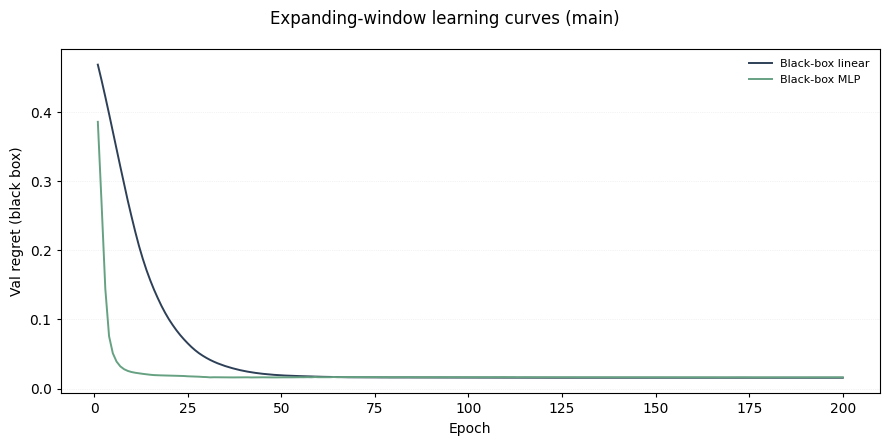

In [24]:
if not training_history.empty:
    for split_name, split_hist in training_history.groupby("split"):
        padded = []
        for model_name, mg in split_hist.groupby("model"):
            max_epoch = int(mg["epoch"].max())
            for _, g in mg.groupby("test_date"):
                gg = (g.sort_values("epoch").set_index("epoch")[["val_loss"]]
                       .reindex(range(1, max_epoch + 1)).ffill().reset_index())
                gg["model"] = model_name
                padded.append(gg)
        mean_history = (pd.concat(padded, ignore_index=True)
                        .groupby(["model", "epoch"], as_index=False)
                        .agg(mean_val_loss=("val_loss", "mean")))

        fig, ax = plt.subplots(figsize=(9, 4.5))
        for model_name, group in mean_history.groupby("model"):
            group = group.sort_values("epoch")
            color = MODEL_COLORS.get(model_name, "grey")
            label = MODEL_LABELS.get(model_name, model_name)
            ax.plot(group["epoch"], group["mean_val_loss"], color=color, lw=1.4, label=label)
        ax.set_ylabel("Val regret (black box)"); ax.set_xlabel("Epoch")
        ax.grid(True, axis="y", lw=0.5, alpha=0.3, linestyle=":"); ax.legend(fontsize=8, frameon=False, loc="upper right")
        fig.suptitle(f"Expanding-window learning curves ({split_name})"); plt.tight_layout()
        fig_dir = FIGURES_DIR / split_name
        fig_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(fig_dir / "learning_curves.png", dpi=200, bbox_inches="tight"); plt.show()
